# Electronics Sales Analysis with Pandas

This practice notebook demonstrates a clean pandas workflow for a small electronics sales dataset: data creation, inspection, cleaning, feature engineering, aggregation, pivot tables, and visualization.

**Dataset notes**
- Each row represents one order.
- `Product` and `Price` intentionally contain missing values for cleaning practice.
- Prices are assumed to be in INR.


## 1. Setup

Import the required libraries and set notebook display options.


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:.2f}".format)
plt.style.use("seaborn-v0_8-whitegrid")


## 2. Create the Dataset

Build a small DataFrame that includes realistic missing values.


In [42]:
sales_data = {
    "Order_ID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    "Product": [
        "Laptop", "Mouse", "Keyboard", "Monitor", "Laptop",
        "Mouse", "Chair", np.nan, "Monitor", "Keyboard"
    ],
    "Category": [
        "Electronics", "Accessories", "Accessories", "Electronics", "Electronics",
        "Accessories", "Furniture", "Furniture", "Electronics", "Accessories"
    ],
    "Region": ["North", "South", "North", "West", "South", "North", "West", "South", "North", "West"],
    "Price": [55000, 500, 1200, 15000, 58000, 450, 3500, np.nan, 14500, 1100],
    "Quantity": [1, 3, 2, 1, 1, 5, 2, 1, 2, 4],
    "Order_Date": [
        "2026-01-05", "2026-01-06", "2026-01-10", "2026-02-01", "2026-02-15",
        "2026-02-20", "2026-03-01", "2026-03-05", "2026-03-10", "2026-03-15"
    ],
}

df_raw = pd.DataFrame(sales_data)
df_raw


,Order_ID,Product,Category,Region,Price,Quantity,Order_Date
0,101,Laptop,Electronics,North,55000.00,1,2026-01-05
1,102,Mouse,Accessories,South,500.00,3,2026-01-06
2,103,Keyboard,Accessories,North,1200.00,2,2026-01-10
3,104,Monitor,Electronics,West,15000.00,1,2026-02-01
4,105,Laptop,Electronics,South,58000.00,1,2026-02-15
5,106,Mouse,Accessories,North,450.00,5,2026-02-20
6,107,Chair,Furniture,West,3500.00,2,2026-03-01
7,108,NaN,Furniture,South,NaN,1,2026-03-05
8,109,Monitor,Electronics,North,14500.00,2,2026-03-10
9,110,Keyboard,Accessories,West,1100.00,4,2026-03-15


## 3. Inspect the Data

Check shape, data types, and missing values before making changes.


In [43]:
df = df_raw.copy()

overview = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_values": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(2),
})

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
overview


Rows: 10, Columns: 7


,column,dtype,missing_values,missing_percent
0,Order_ID,int64,0,0.00
1,Product,str,1,10.00
2,Category,str,0,0.00
3,Region,str,0,0.00
4,Price,float64,1,10.00
5,Quantity,int64,0,0.00
6,Order_Date,str,0,0.00


## 4. Clean and Prepare the Data

Convert date values, fill missing product names, impute missing prices by category, and calculate total sales.


In [44]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Product"] = df["Product"].fillna("Unknown")

category_average_price = df.groupby("Category")["Price"].transform("mean")
df["Price"] = df["Price"].fillna(category_average_price)

df["Total_Sales"] = df["Price"] * df["Quantity"]
df["Month"] = df["Order_Date"].dt.to_period("M")

df


,Order_ID,Product,Category,Region,Price,Quantity,Order_Date,Total_Sales,Month
0,101,Laptop,Electronics,North,55000.00,1,2026-01-05,55000.00,2026-01
1,102,Mouse,Accessories,South,500.00,3,2026-01-06,1500.00,2026-01
2,103,Keyboard,Accessories,North,1200.00,2,2026-01-10,2400.00,2026-01
3,104,Monitor,Electronics,West,15000.00,1,2026-02-01,15000.00,2026-02
4,105,Laptop,Electronics,South,58000.00,1,2026-02-15,58000.00,2026-02
5,106,Mouse,Accessories,North,450.00,5,2026-02-20,2250.00,2026-02
6,107,Chair,Furniture,West,3500.00,2,2026-03-01,7000.00,2026-03
7,108,Unknown,Furniture,South,3500.00,1,2026-03-05,3500.00,2026-03
8,109,Monitor,Electronics,North,14500.00,2,2026-03-10,29000.00,2026-03
9,110,Keyboard,Accessories,West,1100.00,4,2026-03-15,4400.00,2026-03


## 5. Analysis Questions

Use pandas filtering, grouping, sorting, and pivot tables to answer common business questions.


In [45]:
north_high_value_orders = df.loc[
    (df["Region"] == "North") & (df["Total_Sales"] > 5000),
    ["Order_ID", "Product", "Category", "Region", "Total_Sales"]
]

north_high_value_orders


,Order_ID,Product,Category,Region,Total_Sales
0,101,Laptop,Electronics,North,55000.00
8,109,Monitor,Electronics,North,29000.00


In [46]:
category_sales = (
    df.groupby("Category", as_index=False)["Total_Sales"]
    .sum()
    .sort_values("Total_Sales", ascending=False)
)

category_sales


,Category,Total_Sales
1,Electronics,157000.00
0,Accessories,10550.00
2,Furniture,10500.00


In [47]:
region_sales = (
    df.groupby("Region", as_index=False)["Total_Sales"]
    .sum()
    .sort_values("Total_Sales", ascending=False)
)

top_region = region_sales.iloc[0]
print(f"Top region: {top_region['Region']} with total sales of {top_region['Total_Sales']:.2f}")
region_sales


Top region: North with total sales of 88650.00


,Region,Total_Sales
0,North,88650.00
1,South,63000.00
2,West,26400.00


In [48]:
top_orders = (
    df.sort_values("Total_Sales", ascending=False)
    .loc[:, ["Order_ID", "Product", "Category", "Region", "Total_Sales"]]
    .head(3)
)

top_orders


,Order_ID,Product,Category,Region,Total_Sales
4,105,Laptop,Electronics,South,58000.00
0,101,Laptop,Electronics,North,55000.00
8,109,Monitor,Electronics,North,29000.00


In [49]:
monthly_sales = (
    df.groupby("Month", as_index=False)["Total_Sales"]
    .sum()
    .sort_values("Month")
)

monthly_sales["Month"] = monthly_sales["Month"].astype(str)
monthly_sales


,Month,Total_Sales
0,2026-01,58900.00
1,2026-02,75250.00
2,2026-03,43900.00


In [50]:
sales_pivot = df.pivot_table(
    index="Region",
    columns="Category",
    values="Total_Sales",
    aggfunc="sum",
    fill_value=0,
    margins=True,
)

sales_pivot


Category,Accessories,Electronics,Furniture,All
Region,,,,
North,4650.00,84000.00,0.00,88650.00
South,1500.00,58000.00,3500.00,63000.00
West,4400.00,15000.00,7000.00,26400.00
All,10550.00,157000.00,10500.00,178050.00


## 6. Visualize the Results

Create a compact dashboard for sales by category, sales by region, monthly trend, and product contribution.


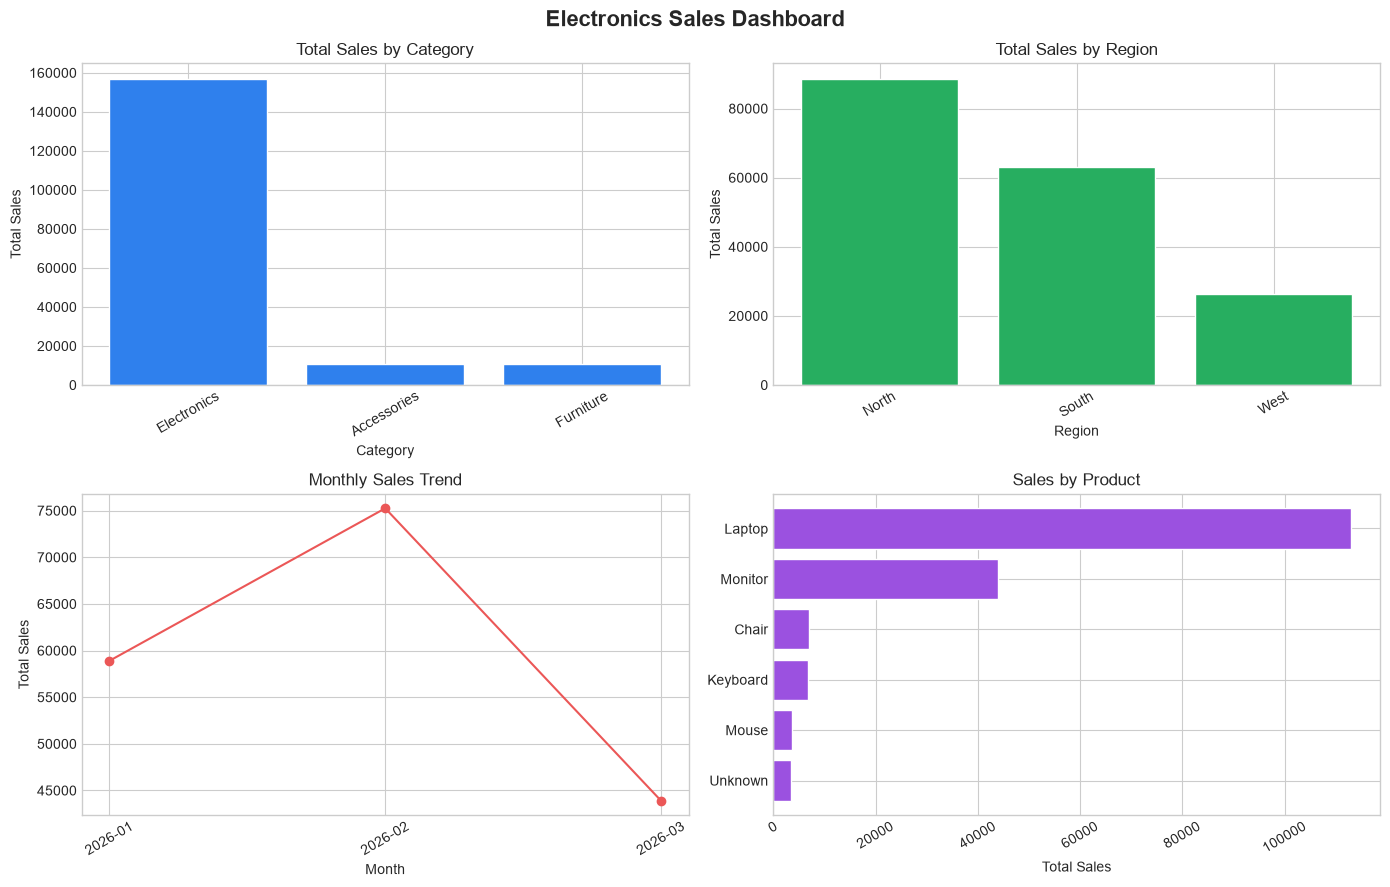

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Electronics Sales Dashboard", fontsize=16, fontweight="bold")

axes[0, 0].bar(category_sales["Category"], category_sales["Total_Sales"], color="#2F80ED")
axes[0, 0].set_title("Total Sales by Category")
axes[0, 0].set_xlabel("Category")
axes[0, 0].set_ylabel("Total Sales")

axes[0, 1].bar(region_sales["Region"], region_sales["Total_Sales"], color="#27AE60")
axes[0, 1].set_title("Total Sales by Region")
axes[0, 1].set_xlabel("Region")
axes[0, 1].set_ylabel("Total Sales")

axes[1, 0].plot(monthly_sales["Month"], monthly_sales["Total_Sales"], marker="o", color="#EB5757")
axes[1, 0].set_title("Monthly Sales Trend")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Total Sales")

product_sales = df.groupby("Product", as_index=False)["Total_Sales"].sum().sort_values("Total_Sales")
axes[1, 1].barh(product_sales["Product"], product_sales["Total_Sales"], color="#9B51E0")
axes[1, 1].set_title("Sales by Product")
axes[1, 1].set_xlabel("Total Sales")

for ax in axes.ravel():
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 7. Key Takeaways

- Electronics produces the highest revenue because laptop and monitor orders have much larger prices.
- The North region has strong revenue from electronics orders.
- Category-level price imputation is more meaningful than filling missing prices with a global average.
- Using clear column names like `Total_Sales` prevents confusion later in the analysis.
